---
title: Advanced Statistical Data Analysis
authors:
  - name: Andreas Ruckstuhl
    affiliation: ZHAW School of Engineering
  - name: Anna Drewek
    affiliation: ZHAW School of Engineering
exports:
- format: pdf
  template: https://github.com/marbetschar/plain_latex_article/archive/refs/heads/main.zip
  output: Advanced-Statistical-Data-Analysis.pdf
  id: advanced-statistical-data-analysis-pdf
downloads:
  - id: advanced-statistical-data-analysis-pdf
    title: Download as PDF
---

In [30]:
install.packages("gRbase")

library(gRbase)

set.seed(123)


The downloaded binary packages are in
	/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T//RtmpjKUKyK/downloaded_packages




## Theoretical Foundations

### Statistical Data Analysis Overview

```{note}
Statistical data analysis is the science of collecting, exploring, and presenting (large amounts of) data to discover underlying patterns and trends which are hidden by random noise.
```

The course focuses on **regression modeling** as a primary tool for explaining relationships between:
- **Response variable** (output/dependent variable): The variable we want to explain or predict
- **Explanatory variables** (inputs/independent variables/predictors): Variables that explain the response

**Mathematical Formulation:**
$$Y \approx f\left\langle X^{(1)}, X^{(2)}, \ldots, X^{(m)}\right\rangle + E$$
where $f\left\langle \cdot \right\rangle$ is the systematic component and $E$ is the random error term.

---

## Part I: Advanced Regression Modelling

---

### Week 1-2: Review of Multiple Linear Regression

#### Objectives of Regression Analysis
1. General description of data structure.
2. Assessment of the effect of explanatory variables on the response.
3. Prediction of future observations.

:::{prf:definition} Multiple Linear Regression Model
:label: mlr-equation

The systematic relationship is explored via a function $f(\cdot)$:
$$Y_i = \beta_0 + \beta_1 x^{(1)}_i + \dots + \beta_m x^{(m)}_i + \mathcal{E}_i, \quad i = 1, \dots, n$$ (mlr-equation)

where $\mathcal{E}_i$ are unobservable random variables.
:::

:::{prf:remark}
In a **linear model**, the parameters enter linearly; the predictors themselves do not have to be linear. For example, $y \approx \beta_0 + \beta_1 x^{(1)} + \beta_2 \log(x^{(2)})$ is a linear model, but $y \approx \beta_0 + \beta_1 (x^{(1)})^{\beta_2}$ is not.
:::

#### Error Assumptions
The standard assumptions for the error terms $\mathcal{E}_i$ are:
- Stochastically independent.
- Expectation zero and constant variance $\sigma^2$ (homoscedasticity).
- Normally (Gaussian) distributed: $\mathcal{E}_i \sim \mathcal{N}(0, \sigma^2)$.

#### Matrix Representation

To simplify notation, the regression equation {eq}`mlr-equation` is written in matrix form:
$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\mathcal{E}}$$

where:
- $\mathbf{Y}$ is an $n \times 1$ vector of responses.
- $\mathbf{X}$ is an $n \times p$ matrix of explanatory variables (including a column of 1s for the intercept).
- $\boldsymbol{\beta}$ is a $p \times 1$ vector of unknown coefficients ($p = m+1$).
- $\boldsymbol{\mathcal{E}}$ is an $n \times 1$ vector of unobserved random variables.

#### Tukey's First-Aid Transformations

Standard recommendations used to linearize relationships and stabilize variance when there is no specific domain theory to guide variable transformation.
These should be applied to both explanatory variables and responses unless a valid reason exists to do otherwise:

| Data Type | Recommended Transformation                                                  |
| :--- |:----------------------------------------------------------------------------|
| **Concentrations and Amounts** | $\log(x)$                                                                   |
| **Count Data** | $\sqrt{x}$                                                                  |
| **Counted Fractions / Shares** | $\tilde{x} = \text{logit}(x) = \log\left(\frac{x + 0.005}{1.01 - x}\right)$ |

#### Model Fitting and Diagnostics

##### Least Squares Estimation
The coefficients $\boldsymbol{\beta}$ are estimated by minimizing the sum of squared residuals.

:::{prf:theorem} Gauss-Markov Theorem
:label: thm-gauss-markov
Under the assumptions of zero mean, constant variance, and uncorrelated errors, the Ordinary Least Squares (OLS) estimator is the **Best Linear Unbiased Estimator (BLUE)**.
:::

The OLS estimator is given by:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$$

##### Model Adequacy (Residual Analysis)
Model adequacy is checked using diagnostic plots:
- **Tukey-Anscombe Plot:** Residuals vs. Fitted values to check for non-linearity or heteroscedasticity.
- **Normal Q-Q Plot:** To check the normality assumption of errors.
- **Scale-Location Plot:** To check for constant variance.
- **Residuals vs. Leverage:** To identify influential observations (Cook's Distance).

**Model Formulation:**
$$Y_i = \beta_0 + \beta_1 x_i^{(1)} + \beta_2 x_i^{(2)} + \cdots + \beta_m x_i^{(m)} + E_i, \quad i = 1, \ldots, n$$

**Assumptions:**
1. $E_i \sim \mathcal{N}(0, \sigma^2)$ (normally distributed errors)
2. $\mathbb{E}[E_i] = 0$ (zero expectation)
3. $\text{Var}(E_i) = \sigma^2$ (homoscedasticity)
4. $E_i$ are stochastically independent
5. No perfect multicollinearity

**Matrix Notation:**
$$\underline{Y} = \boldsymbol{X} \underline{\beta} + \underline{E}$$

```{math}
:label: eq-linear-model
Y = X\beta + E
```

**Gauss-Markov Theorem:**
Under assumptions 1-4 (without normality), OLS is BLUE (Best Linear Unbiased Estimator).

**Properties:**
- Unbiased: $\mathbb{E}[\hat{\underline{\beta}}] = \underline{\beta}$
- Consistent: $\hat{\underline{\beta}} \xrightarrow{P} \underline{\beta}$
- Asymptotic Normality: $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \sigma^2 (\boldsymbol{X}^T \boldsymbol{X})^{-1})$

#### Learning Objectives
- Introduces various problems solvable with advanced regression modelling
- Explains models and inference methods for common cases
- Familiarizes with the statistical modelling approach
- Introduces R for solving regression problems

#### Key R Code Snippets

```{code-block} R
---
name: lm-basic
---
# Basic linear regression with mtcars dataset
mtc1.lm1 <- lm(lMPG ~ lDisp + lHP + lWT + drat + qsec + wCarb + wCyl + wGear + VS + AM,
               data = mtcars1)

# Diagnostic plots
source("../RFn_Plot-lmSim.R")
plot(mtc1.lm1, which = 1:3)
plot.lmSim(mtc1.lm1, which = 1:3, SEED = 4711)
```

```{code-block} R
---
name: lm-assumptions-check
---
library(lmtest)
library(car)

# Breusch-Pagan test for heteroscedasticity
bptest(mtc1.lm1)

# Shapiro-Wilk test for normality
shapiro.test(residuals(mtc1.lm1))

# Variance Inflation Factor
vif(mtc1.lm1)

# Durbin-Watson test for autocorrelation
dwtest(mtc1.lm1)
```

---

### Week 3: Advanced Topics in Linear Regression Modelling

#### Theoretical Background

**Weighted Least Squares:**
$$\hat{\underline{\beta}}_{WLS} = (\boldsymbol{X}^T \boldsymbol{W} \boldsymbol{X})^{-1} \boldsymbol{X}^T \boldsymbol{W} \underline{Y}$$
where $\boldsymbol{W} = \text{diag}(w_i)$ with $w_i = 1/\sigma_i^2$.

**Robust Regression:**
- **Huber's method:** Quadratic loss for small residuals, linear for large
- **RLM:** Iteratively reweighted least squares with Huber's $\psi$ function

**Smooth Function Fitting:**
- **LOESS:** Locally weighted scatterplot smoothing
- **Splines:** Natural cubic, B-splines, thin plate splines

**Additive Models:**
$$g(\mu) = \beta_0 + \sum_{j=1}^m s_j(X_j)$$

#### Learning Objectives
- Weighted Least Squares (for non-constant variance)
- Robust Fitting (to handle outliers and leverage points)
- Fitting Smooth Functions (using LOESS and splines)
- Additive Regression Models
- Model Building strategies

#### Key R Code Snippets

```{code-block} R
---
name: weighted-least-squares
---
model_wls <- lm(y ~ x1 + x2, data = mydata, weights = myweights)
library(MASS)
model_rlm <- rlm(y ~ x1 + x2, data = mydata)
```

```{code-block} R
---
name: smooth-functions
---
model_loess <- loess(y ~ x1 + x2, data = mydata, span = 0.75)
library(splines)
model_spline <- lm(y ~ bs(x1, df = 3) + bs(x2, df = 3), data = mydata)
```

```{code-block} R
---
name: additive-models
---
library(mgcv)
model_gam <- gam(y ~ s(x1) + s(x2) + s(x3), data = mydata)
```

---

### Week 4: Binary Regression (Logistic Regression)

#### Theoretical Background

**Logistic Regression Model:**
$$P(Y_i = 1 | \underline{X}_i) = \pi_i = \frac{1}{1 + e^{-\eta_i}}, \quad \eta_i = \underline{X}_i^T \underline{\beta}$$

**Logit Link:**
$$\log\left\langle \frac{\pi_i}{1 - \pi_i} \right\rangle = \eta_i$$

**Odds Ratio:**
$$\text{OR} = e^{\beta_j} = \frac{\text{Odds}(Y=1 | X_j = x+1)}{\text{Odds}(Y=1 | X_j = x)}$$

**Asymptotic Properties:**
- $\hat{\underline{\beta}} \sim \mathcal{N}(\underline{\beta}, \mathcal{I}^{-1})$
- Wald tests valid for large samples

#### Learning Objectives
- Know the Logistic Regression Model and its applications
- Fit a Logistic Regression in R
- Interpret the parameters of a Logistic Regression

#### Key R Code Snippets

```{code-block} R
---
name: logistic-regression
---
SPP.glm1 <- glm(promoted ~ sales, family = binomial, data = SPP)
summary(SPP.glm1)
# Odds increase by factor of exp(0.02439536 * 50) = 3.39
```

```{code-block} R
---
name: logistic-aggregated
---
SPPg.glm1 <- glm(cbind(Y, m-Y) ~ sales, family = binomial, data = SPPg)
```

```{code-block} R
---
name: logistic-visualization
---
h1 <- table(SPP$sales, SPP$promoted)
h2 <- data.frame(Y = h1[, "1"], m = h1[, "0"] + h1[, "1"],
                 ac = as.numeric(dimnames(h1)[[1]]))
SPPg <- data.frame(h2, prop = h2$Y/h2$m)
par(mfrow = c(1, 2), las = 1)
plot(prop ~ sales, data = SPPg, ylim = c(0, 1.05),
     xlab = "sales", ylab = "Proportion promoted", type = "n")
symbols(y = SPPg$prop, x = SPPg$sales, circles = sqrt(SPPg$m),
        inches = 0.15, add = TRUE)
```

---

### Week 5: GLM - A Unifying Model Family

#### Theoretical Background

**GLM Structure:**
1. **Random:** $Y_i \sim \text{Exponential Family}(\mu_i, \phi)$
2. **Systematic:** $\eta_i = \underline{x}_i^T \underline{\beta}$
3. **Link:** $g(\mu_i) = \eta_i$

**Exponential Family:**
$$f(y_i; \mu_i, \phi) = \exp \left\langle \frac{y_i b(\mu_i) - c(\mu_i)}{\phi} w_i + d(y_i; \phi, w_i) \right\rangle$$

```{math}
:label: eq-exponential-family
f(y; \mu, \phi) = \exp\left\langle \frac{y b(\mu) - c(\mu)}{\phi} + d(y; \phi) \right\rangle
```

**Variance Function:**
$$\text{Var}(Y_i) = \frac{\phi}{w_i} V(\mu_i), \quad V(\mu_i) = \frac{1}{b''(\mu_i)}$$

**Common Distributions:**

| Distribution | Range | $\mu$ | Variance | Canonical Link | $V(\mu)$ |
|-------------|-------|-------|----------|----------------|-----------|
| Gaussian | $\mathbb{R}$ | $\mu$ | $\sigma^2$ | Identity | $1$ |
| Binomial | $\{0,...,m\}$ | $\pi$ | $\pi(1-\pi)/m$ | Logit | $\mu(1-\mu)$ |
| Poisson | $\{0,1,2,...\}$ | $\lambda$ | $\lambda$ | Log | $\mu$ |
| Gamma | $(0,\infty)$ | $\mu$ | $\mu^2/\nu$ | Inverse | $\mu^2$ |

**IRLS Algorithm:**
1. $z = \eta + (y - \mu) \frac{\partial \eta}{\partial \mu}$
2. $W = \text{diag}\left\langle \frac{w}{\phi V(\mu) (\frac{\partial \eta}{\partial \mu})^2} \right\rangle$
3. Fit weighted linear regression
4. Update and repeat

#### Learning Objectives
- Identify members of the exponential family
- Know the two basic elements that define the GLM
- Fit GLMs in R and know the algorithm underlying it
- Interpret R output of a GLM fit

#### Key R Code Snippets

```{code-block} R
---
name: glm-unifying
---
model_binomial <- glm(y ~ x1 + x2, family = binomial, data = mydata)
model_poisson <- glm(y ~ x1 + x2, family = poisson, data = mydata)
model_gamma <- glm(y ~ x1 + x2, family = Gamma, data = mydata)
model_gaussian <- glm(y ~ x1 + x2, family = gaussian, data = mydata)
```

```{code-block} R
---
name: glm-fitting
---
DaR.glm <- glm(RDR ~ sPOP + lAR + HR + sVH + F + IND,
               family = poisson, data = DaR)
par(mfrow = c(2, 4), mar = c(3.5, 3.5, 2, 1.5))
plot(DaR.glm)
```

---

### Week 6: Inference, Model Simplification, Variable Selection

#### Theoretical Background

**Deviance:**
$$D(\underline{y}, \hat{\underline{\mu}}) = 2 \sum_i \left\langle \ell(y_i; y_i) - \ell(y_i; \hat{\mu}_i) \right\rangle$$

**Deviance Test:**
$$\Delta D = D_0 - D_1 \sim \chi^2_{df_1 - df_0}$$

**Overdispersion:**
$$\hat{\phi} = \frac{\text{Residual Deviance}}{n - p}$$

**Confidence Intervals:**
- **Wald:** $\hat{\beta}_j \pm z_{\alpha/2} \cdot \text{SE}(\hat{\beta}_j)$
- **Deviance-based:** More accurate for small samples
- **Bootstrap:** Nonparametric

#### Learning Objectives
- Know what deviances are in GLM
- Know what overdispersion is and can identify it
- Know when to apply Wald-type vs deviance-based confidence intervals
- Apply methods in statistical data analysis using R

#### Key R Code Snippets

```{code-block} R
---
name: glm-deviances
---
model <- glm(y ~ x1 + x2, family = poisson, data = mydata)
null_deviance <- model$null.deviance
resid_deviance <- model$deviance
anova(model_simple, model_complex, test = "LRT")
```

```{code-block} R
---
name: glm-overdispersion
---
model_poisson <- glm(y ~ x1 + x2, family = poisson, data = mydata)
dispersion <- model_poisson$deviance / model_poisson$df.residual
if (dispersion > 1.5) {
  model_quasi <- glm(y ~ x1 + x2, family = quasipoisson, data = mydata)
  library(MASS)
  model_nb <- glm.nb(y ~ x1 + x2, data = mydata)
}
```

```{code-block} R
---
name: model-selection
---
AIC(model1, model2, model3)
BIC(model1, model2, model3)
step(model1, direction = "both")
```

---

### Week 7: Diagnostics / Model Adequacy Checking

#### Theoretical Background

**Diagnostic Plots:**
1. **Residuals vs Fitted:** Check linearity and homoscedasticity
2. **Normal Q-Q:** Check normality
3. **Scale-Location:** Check constant variance
4. **Leverage:** Identify influential points

**Multicollinearity:**
- High VIF (> 5 or 10) indicates problematic collinearity
- Effects: Unstable estimates, inflated standard errors

#### Learning Objectives
- Understand how AIC is generalized to GLMs
- Check model adequacy and determine which assumptions are violated
- Find appropriate transformations of predictors in a data-driven manner
- Apply methods in statistical data analysis using R

#### Key R Code Snippets

```{code-block} R
---
name: aic-glm
---
AIC(model1, model2)
```

```{code-block} R
---
name: glm-diagnostics
---
par(mfrow = c(2, 2))
plot(model_poisson, which = 1:4)
library(halfnorm)
halfnorm(residuals(model_poisson, type = "deviance"))
```

```{code-block} R
---
name: influence-measures
---
library(car)
cooks.distance(model1)
hat.values(model1)
dfbetas(model1)
```

---

### Week 8: Some Extensions of GLM

#### Theoretical Background

**Rate Models:**
$$\mathbb{E}[Y_i] = \mu_i = t_i \lambda_i$$
For Poisson with log link:
$$\log(\mu_i) = \log(t_i) + \log(\lambda_i) = \underline{x}_i^T \underline{\beta}$$

**Quasi Models:**
$$\text{Var}(Y_i) = \phi V(\mu_i)$$
- Consistent $\hat{\underline{\beta}}$ even if variance function misspecified
- Standard errors adjusted by $\hat{\phi}$

**Instrumental Variables:**
1. **First Stage:** $X = \pi_0 + \pi_1 Z + U$
2. **Second Stage:** $Y = \beta_0 + \beta_1 \hat{X} + E$

#### Learning Objectives
- Know what a rate model is and how to analyse it with GLM
- Know how a quasi model extends a GLM and when to apply it
- Fit methods to data, interpret results, make inference and predictions

#### Key R Code Snippets

```{code-block} R
---
name: rate-model
---
model_rate <- glm(y ~ x1 + x2, family = poisson, offset = log(t), data = mydata)
```

```{code-block} R
---
name: quasi-models
---
model_quasipoisson <- glm(y ~ x1 + x2, family = quasipoisson, data = mydata)
model_quasibinomial <- glm(cbind(Y, m-Y) ~ x1 + x2, family = quasibinomial, data = mydata)
```

```{code-block} R
---
name: instrumental-variables
---
library(AER)
model_iv <- ivreg(Y ~ X + W | Z + W, data = mydata)
summary(model_iv)
```

## Part II: Causality

### Causality 1: Introduction

#### Theoretical Background

```{warning}
Association does not imply causation.
```

**The Ladder of Causation (Pearl):**
1. **Association (Seeing):** Observing patterns
2. **Intervention (Doing):** Estimating effects of actions
3. **Counterfactuals (Imagining):** Reasoning about hypotheticals

**Notation:**
- $P(Y | X = x)$: Conditional probability
- $P(Y | \text{do}(X = x))$: Causal effect

**Causal Graphical Models:**
- **Nodes:** Variables
- **Edges:** Causal relationships
- **DAG:** Directed Acyclic Graph (no cycles)

**Graphical Structures:**
1. **Chain:** $X → Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
2. **Fork:** $X ← Z → Y$
  - $X$ and $Y$ are **conditionally independent** given Z; $(X \perp\!\!\!\perp Y \mid Z)$
3. **Collider:** $X → Z ← Y$
  - $X$ and $Y$ are **independent** $(X \perp\!\!\!\perp Y)$, but are **conditionally dependent** on Z and any descendants of Z; $(X \not\perp\!\!\!\perp Y \mid Z)$

```{math}
:label: def-dseparation
X \perp\!\!\!\perp Y \mid Z \text{ if all paths between X and Y are blocked by Z}
```

#### Learning Objectives
- Understand when and why causal reasoning is important
- Be familiar with causal graphical models
- Understand the difference between association, interventions, and counterfactuals
- Know the difference between experimental and observational data

#### Intervention changes distribution

![Intervention changes distribution 1](advanced-statistical-data-analysis/Intervention-changes-distribution-1.png)

![Intervention changes distribution 2](advanced-statistical-data-analysis/Intervention-changes-distribution-2.png)

#### Key R Code Snippets

In [31]:
library(gRbase)
g <- dag(
  c("A"),
  c("B", "A", "E"), # = root node + all incoming node-edges
  c("C", "A", "B", "D"),
  c("D", "B"),
  c("E")
)

cat("Children of B = ", children("B", g), "\n")
cat("Parents of B = ", parents("B", g), "\n")
cat("Ancestors of B = ", ancestralSet("B", g), "\n")

Children of B =  C D 
Parents of B =  A E 
Ancestors of B =  A B E 


,A,B,E,C,D
A,0,1,0,1,0
B,0,0,0,1,1
E,0,1,0,0,0
C,0,0,0,0,0
D,0,0,0,1,0


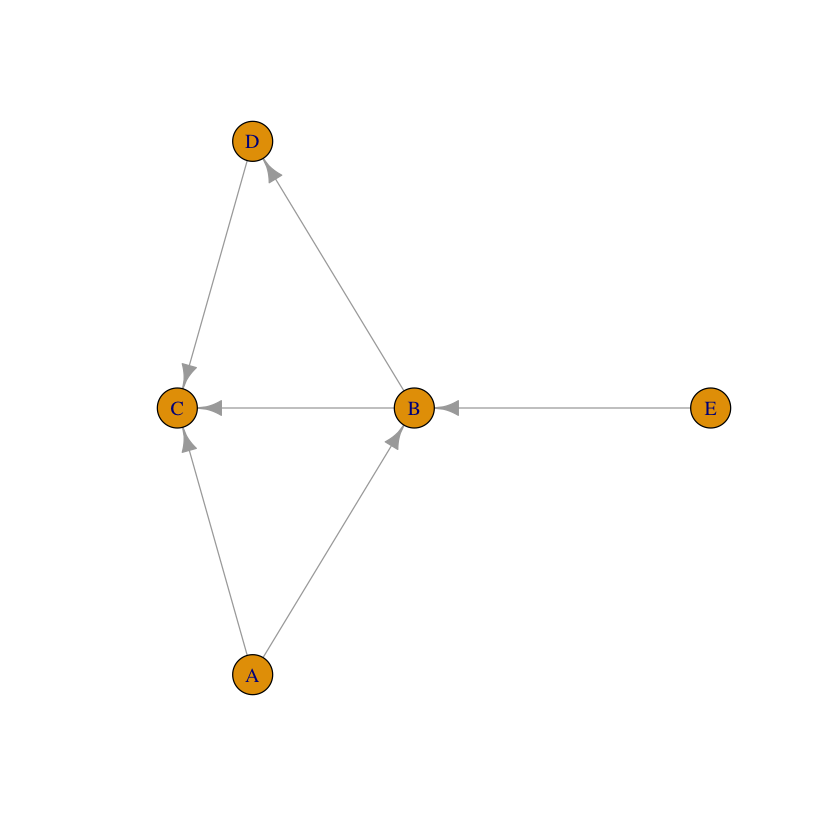

In [32]:
m <- as(g, "matrix") # to matrix from graph
m
g1 <- as(m, "igraph") # to igraph from matrix
plot(g1)

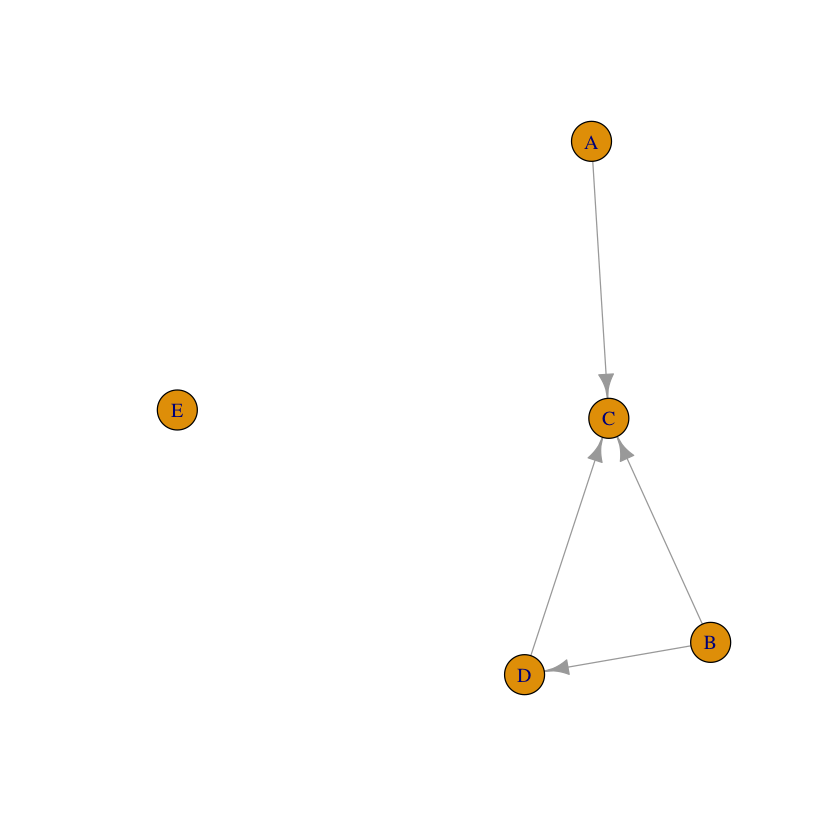

In [34]:
# Intervention on B (i.e. remove edges):
g2 <- removeEdge("A", "B", removeEdge("E", "B", g1))
plot(g2)

### Causality 2: Simpson's Paradox & Graphical Models

#### Theoretical Background

**Simpson's Paradox:**
A trend appears in different groups but disappears or reverses when combined.

**Factorization:**
- **Chain:** $P(X,Z,Y) = P(X)P(Z|X)P(Y|Z)$
- **Fork:** $P(X,Z,Y) = P(Z)P(X|Z)P(Y|Z)$
- **Collider:** $P(X,Z,Y) = P(X)P(Y)P(Z|X,Y)$

**Bayesian Network:**
$$P(X_1, \ldots, X_n) = \prod_{i=1}^n P(X_i | \text{Parents}(X_i))$$

#### Learning Objectives
- Understand Simpson's paradox and how to analyze it
- Express joint distribution by factorization
- Understand (conditional) independence
- Identify (conditional) independences for chain, fork, and collider

#### Key R Code Snippets

In [12]:
library(gRbase)
library(gRain)

graph.toys <- dag(c("Gender"), c("Toy","Gender"))
load("advanced-statistical-data-analysis/toys.rda")
gn <- grain(graph.toys, data = toys) # combine graph and data to a Bayesian network

In [13]:
# Conditional probability: from data
toys_girls <- toys[toys$Gender== "girl",]
cat("P(Toy = car | Gender = girl) =", sum(toys_girls== "car") / nrow(toys_girls))

# Conditional probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="conditional")

P(Toy = car | Gender = girl) = 0.3915344

,boy,girl
car,0.8931624,0.3915344
doll,0.1068376,0.6084656


In [43]:
# Joint probability: from data
n_car_girl <- sum(toys$Toy== "car" & toys$Gender== "girl")
cat("P(Toy = car, Gender = girl) =", n_car_girl/nrow(toys))

# Joint probability: from the Bayesian network
querygrain(gn, nodes=c("Toy", "Gender"), type="joint")

P(Toy = car, Gender = girl) = 0.1749409

,car,doll
boy,0.4940898,0.05910165
girl,0.1749409,0.27186761


In [45]:
# marginal probabilities
querygrain(gn, nodes = "Gender", type = "marginal")
querygrain(gn, nodes = "Toy", type = "marginal")

$Gender
Gender
      boy      girl 
0.5531915 0.4468085

$Toy
Toy
      car      doll 
0.6690307 0.3309693

,boy,girl
car,0.8989899,0.3939394
doll,0.1010101,0.6060606


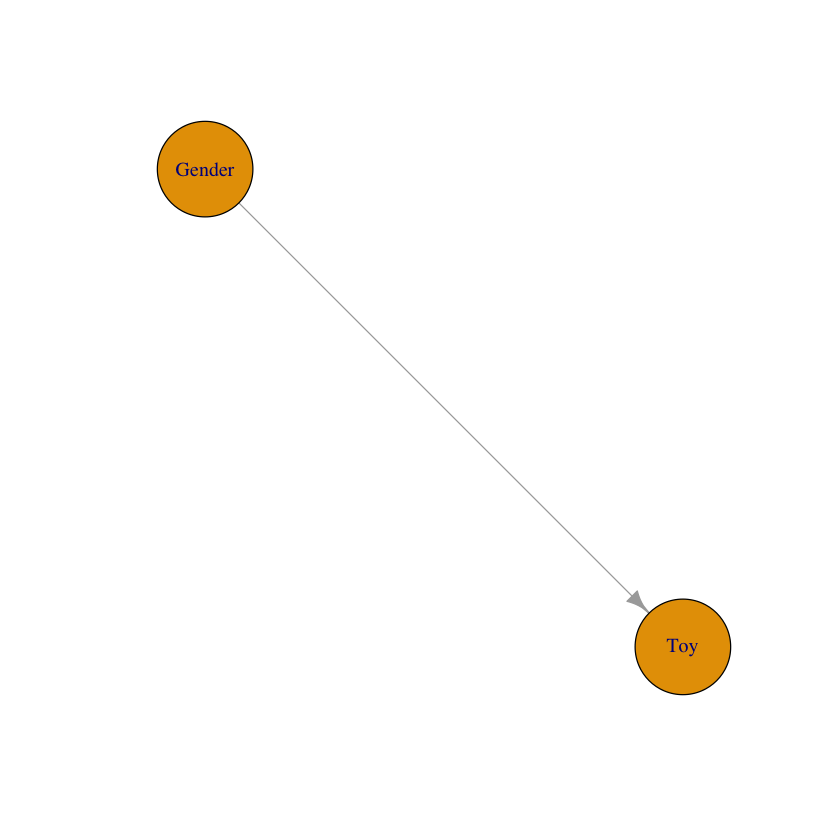

In [16]:
# Manually using a Conditional Probability Table:
gender <- cptable("Gender", values = c(0.55, 0.45), levels = c("boy","girl"))
toy <- cptable("Toy", values = c(0.67, 0.33), levels = c("car","doll"))

toy_gender <- cptable(c("Toy", "Gender"),
  # car:boy = 0.89, doll:boy = 0.10, car:girl = 0.39, doll:girl = 0.60
  values = c(0.89, 0.10, 0.39, 0.60), levels = c("car","doll"))

# Building the Bayesian Network
cpt <- compileCPT(list(gender, toy_gender))
bn <- grain(cpt, compile = FALSE)
plot(bn)

querygrain(bn, nodes=c("Toy", "Gender"), type="conditional")

### Causality 3: D-Separation & Causal Effect Estimation

#### Theoretical Background

**D-Separation:**

X and Y are d-separated given Z if all paths between X and Y are blocked by Z if and only if:

1. a middle node of a chain (X → B → Y) or a fork (X ← B → Y) is conditioned on (i.e. it is in Z)
2. a middle node of a collider (X → B ← Y) is **_not_** conditioned on (i.e. is _not_ in Z), and no descendant of B is in Z.

If Z blocks every path between two nodes X and Y, then X and Y are d-separated conditioning on Z and thus are conditionally independent on Z.

**Adjustment Formula:**
$$P(Y | \text{do}(X = x)) = \sum_z P(Y | X = x, Z = z) P(Z = z)$$

**Backdoor Criterion:**
Z satisfies backdoor criterion if:
1. Z blocks all backdoor paths from X to Y
2. Z does not contain any descendants of X

#### Learning Objectives
- Know D-Separation
- Estimate causal effect using the adjustment formula
- Define adjustment sets with the backdoor criterion

Are E and D d-separated by Z = {B}? TRUE 
Are E and C d-separated by Z = {A}? FALSE 
Are A and D d-separated by Z = {B, C}? FALSE 


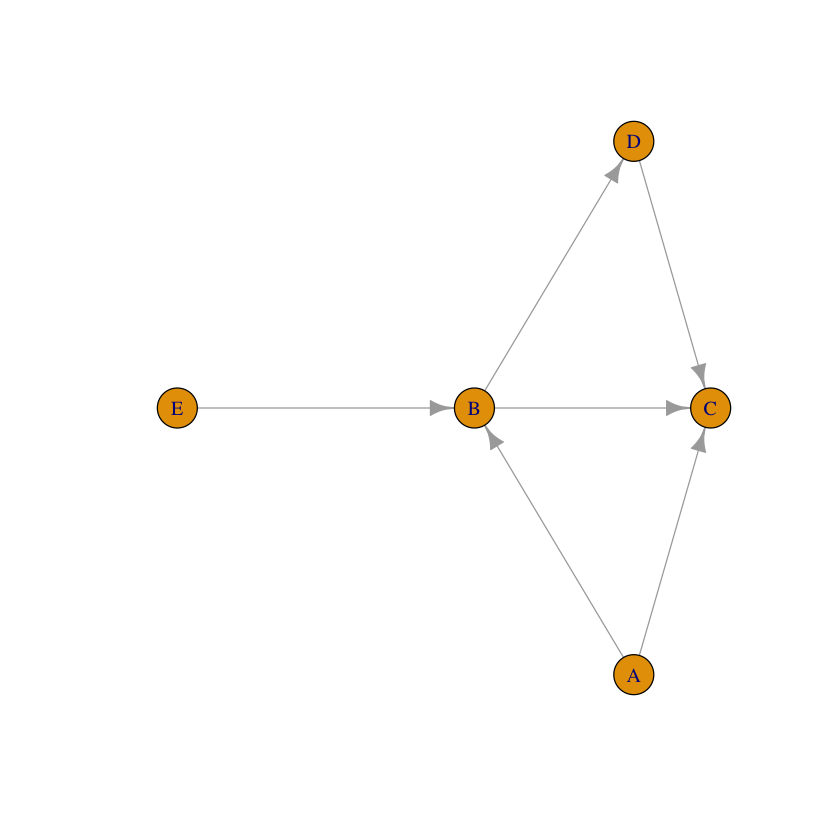

In [41]:
library(gRbase)
# List all nodes with their parents
g <- dag("A",c("B","A","E"),c("C","A","B","D"),c("D","B"),c("E"))
d.separates <- function(a,b,c,dag){
    separates(a,b,c, moralize(ancestralGraph(union(union(a,b),c),dag)))
}
plot(g)
cat("Are E and D d-separated by Z = {B}?", d.separates("E", "D", c("B"), g), "\n")
cat("Are E and C d-separated by Z = {A}?", d.separates("E", "C", c("A"), g), "\n")
cat("Are A and D d-separated by Z = {B, C}?", d.separates("A", "D", c("B", "C"), g), "\n")

### Causality 4: Structural Causal Models

#### Theoretical Background

**Linear SCM:**
$$\begin{aligned}
X &= f_X(E_X) \\
W &= 5X + 10Z + E_W \\
Y &= 12W + E_Y
\end{aligned}$$

**Direct vs. Total Effects:**
- **Total:** Effect through all paths
- **Direct:** Effect through direct path only

#### Learning Objectives
- Be familiar with (linear) structural causal models
- Understand direct and total causal effects
- Estimate direct and total causal effect from linear SCM

#### Key R Code Snippets

```{code-block} R
---
name: scm-simulation
---
set.seed(123)
n <- 1000
E_X <- rnorm(n); E_Z <- rnorm(n); E_W <- rnorm(n); E_Y <- rnorm(n)
X <- E_X; Z <- E_Z
W <- 5*X + 10*Z + E_W
Y <- 12*W + E_Y
data_scm <- data.frame(X, Z, W, Y)
model_total <- lm(Y ~ X, data = data_scm)
model_direct <- lm(Y ~ X + W, data = data_scm)
```

---

### Causality 5: Advanced Topics

#### Theoretical Background

**Instrumental Variables:**
1. **Relevance:** $\text{Cov}(Z, X) \neq 0$
2. **Exclusion:** Z has no direct effect on Y except through X
3. **Exogeneity:** $\text{Cov}(Z, E) = 0$

**Two-Stage Least Squares:**
1. First stage: $X = \pi_0 + \pi_1 Z + U$
2. Second stage: $Y = \beta_0 + \beta_1 \hat{X} + E$

**Counterfactuals:**
Pearl's three-step method:
1. **Abduction:** Infer unobserved variables
2. **Action:** Set X to new value
3. **Prediction:** Predict new Y

**Markov Equivalence:**
- Chains and forks are Markov equivalent
- Represented by CPDAG

#### Learning Objectives
- Understand instrumental variables
- Be familiar with counterfactual reasoning
- Know the three steps in computing counterfactuals
- Understand Markov Equivalence

#### Key R Code Snippets

```{code-block} R
---
name: instrumental-variables
---
library(AER)
model_iv <- ivreg(Y ~ X + W | Z + W, data = mydata)
summary(model_iv)
first_stage <- lm(X ~ Z + W, data = mydata)
summary(first_stage)
```

```{code-block} R
---
name: markov-equivalence
---
library(pcalg)
dag1 <- dag(c("X", "Z", "Y"), list(c("X", "Z"), c("Z", "Y")))
dag2 <- dag(c("X", "Z", "Y"), list(c("Z", "X"), c("Z", "Y")))
meq(dag1, dag2)
```

---

### Causality 6: Causal Structure Learning

#### Theoretical Background

**PC Algorithm:**
1. Start with fully connected undirected graph
2. Test for conditional independence
3. Remove edges between conditionally independent variables
4. Orient edges using v-structures
5. Propagate orientations

**LiNGAM Algorithm:**
- Assumes linear relationships with non-Gaussian errors
- Uses ICA to identify causal order
- Can identify full causal graph

**Four Steps of Causal Inference:**
1. Create causal model (DAG)
2. Identify causal effect
3. Estimate causal effect
4. Validate

#### Learning Objectives
- Know the steps of PC algorithm and LiNGAM algorithm
- Perform causal structure learning with PC and LiNGAM in R
- Know the 4 steps of causal inference

#### Key R Code Snippets

```{code-block} R
---
name: pc-algorithm
---
library(pcalg)
set.seed(239)
N <- 500000
X <- rnorm(N); Z <- rnorm(N)
W <- 5*X + 10*Z + rnorm(N)
Y <- 12*W + rnorm(N); V <- 8*W + rnorm(N)
dat <- cbind(X, Z, W, Y, V)
suffStat <- list(C = cor(dat), n = nrow(dat))
pc_fit <- pc(suffStat, indepTest = gaussCItest, alpha = 0.01,
             labels = colnames(dat), verbose = TRUE)
plot(pc_fit)
```

```{code-block} R
---
name: lingam-algorithm
---
library(pcalg)
set.seed(123)
N <- 1000
X <- rexp(N, rate = 1); E1 <- rexp(N, rate = 1); E2 <- rexp(N, rate = 1)
Y <- 2*X + E1; Z <- 3*Y + E2
dat <- data.frame(X, Y, Z)
lingam_fit <- lingam(suffStat, labels = colnames(dat))
plot(lingam_fit)
```

---

## Key Packages

| Package | Purpose | Installation | Key Functions |
|---------|---------|-------------|----------------|
| `gRain` | Bayesian networks | `install.packages("gRain")` | `bn`, `querygrain` |
| `gRbase` | Graphical models, DAGs | `install.packages("gRbase")` | `dag`, `dsep` |
| `pcalg` | Causal structure learning | `install.packages("pcalg")` | `pc`, `lingam` |
| `MASS` | Robust regression | `install.packages("MASS")` | `rlm`, `glm.nb` |
| `mgcv` | GAM | `install.packages("mgcv")` | `gam`, `s`, `ti` |
| `AER` | Instrumental variables | `install.packages("AER")` | `ivreg` |
| `boot` | Bootstrap | `install.packages("boot")` | `boot`, `boot.ci` |
| `car` | Diagnostics | `install.packages("car")` | `vif`, `cooks.distance` |
| `lmtest` | Hypothesis testing | `install.packages("lmtest")` | `bptest`, `dwtest` |
| `splines` | Spline regression | `install.packages("splines")` | `bs`, `ns` |

---

## References

### Part I: Advanced Regression Modelling
- Ruckstuhl, A. (2026). *Advanced Statistical Data Analysis - Lecture Notes*. ZHAW.
- Nelder, J. A., & Wedderburn, R. W. M. (1972). Generalized linear models. *JRSS Series A*.
- McCullagh, P., & Nelder, J. A. (1989). *Generalized Linear Models*. Chapman & Hall.
- Fox, J. (2015). *Applied Regression Analysis and GLMs*. Sage.

### Part II: Causality
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference*. Cambridge.
- Pearl, J., Glymour, M., & Jewell, N. P. (2016). *Causal Inference in Statistics*. Wiley.
- Peters, J., Janzing, D., & Schölkopf, B. (2017). *Elements of Causal Inference*. MIT Press.
- Hernán, M. A., & Robins, J. M. (2020). *Causal Inference: What If?*. Chapman & Hall.

---

## Appendix: Mathematical Notation Reference

### Common Symbols

| Symbol | Meaning | Example |
|--------|---------|---------|
| $Y$ | Response variable | $Y_i$ |
| $X$ | Explanatory variable | $X_j$ |
| $\beta$ | Regression coefficient | $\beta_0$, $\beta_1$ |
| $\mu$ | Expectation | $\mu = \mathbb{E}[Y]$ |
| $\sigma^2$ | Variance | $\text{Var}(Y) = \sigma^2$ |
| $\phi$ | Dispersion parameter | $\phi V(\mu)$ |
| $\eta$ | Linear predictor | $\eta = \underline{X}^T \underline{\beta}$ |
| $g(\cdot)$ | Link function | $g(\mu) = \eta$ |
| $P(\cdot)$ | Probability | $P(Y | X)$ |
| $\text{do}(X=x)$ | Intervention | $P(Y | \text{do}(X=x))$ |

### Common Distributions

| Distribution | Notation | Mean | Variance |
|-------------|----------|------|----------|
| Normal | $\mathcal{N}(\mu, \sigma^2)$ | $\mu$ | $\sigma^2$ |
| Binomial | $\text{Binomial}(m, \pi)$ | $m\pi$ | $m\pi(1-\pi)$ |
| Poisson | $\text{Poisson}(\lambda)$ | $\lambda$ | $\lambda$ |
| Gamma | $\text{Gamma}(\alpha, \beta)$ | $\alpha/\beta$ | $\alpha/\beta^2$ |